# Results Visualization & Summary

Generate publication-quality figures summarizing the ML reproduction.
Compare with paper's reported results.

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('../data/results_round1.pkl', 'rb') as f:
    r1 = pickle.load(f)
with open('../data/results_round2.pkl', 'rb') as f:
    r2 = pickle.load(f)

In [2]:
# Comparison table: Round 1 (17 features) vs Round 2 (4 features)
print("Performance Comparison: Round 1 (17 features) vs Round 2 (4 features)")
print("=" * 75)
print(f"{'Model':<25} {'R1 AUC':>8} {'R1 Acc':>8} {'R2 AUC':>8} {'R2 Acc':>8}")
print("=" * 75)
for name in r1['results']:
    r1_auc = r1['results'][name]['auc']
    r1_acc = r1['results'][name]['accuracy']
    r2_auc = r2['results'][name]['auc']
    r2_acc = r2['results'][name]['accuracy']
    print(f"{name:<25} {r1_auc:>8.4f} {r1_acc:>8.4f} {r2_auc:>8.4f} {r2_acc:>8.4f}")
print("=" * 75)
print(f"\nPaper (RF, 4 features): AUC = 0.87 \u00b1 0.06, Accuracy = 0.84")

Performance Comparison: Round 1 (17 features) vs Round 2 (4 features)
Model                       R1 AUC   R1 Acc   R2 AUC   R2 Acc
Random Forest               0.9581   0.8780   0.8984   0.9024
Gradient Boosting           0.9516   0.8293   0.9161   0.9512
XGBoost                     0.9387   0.8537   0.9161   0.9024
Logistic Regression         0.8774   0.8537   0.8452   0.8537
SVC                         0.8839   0.8780   0.7645   0.8780

Paper (RF, 4 features): AUC = 0.87 ± 0.06, Accuracy = 0.84


Saved: /home/yhm/desktop/code/anion-paper/figures/roc_comparison.png


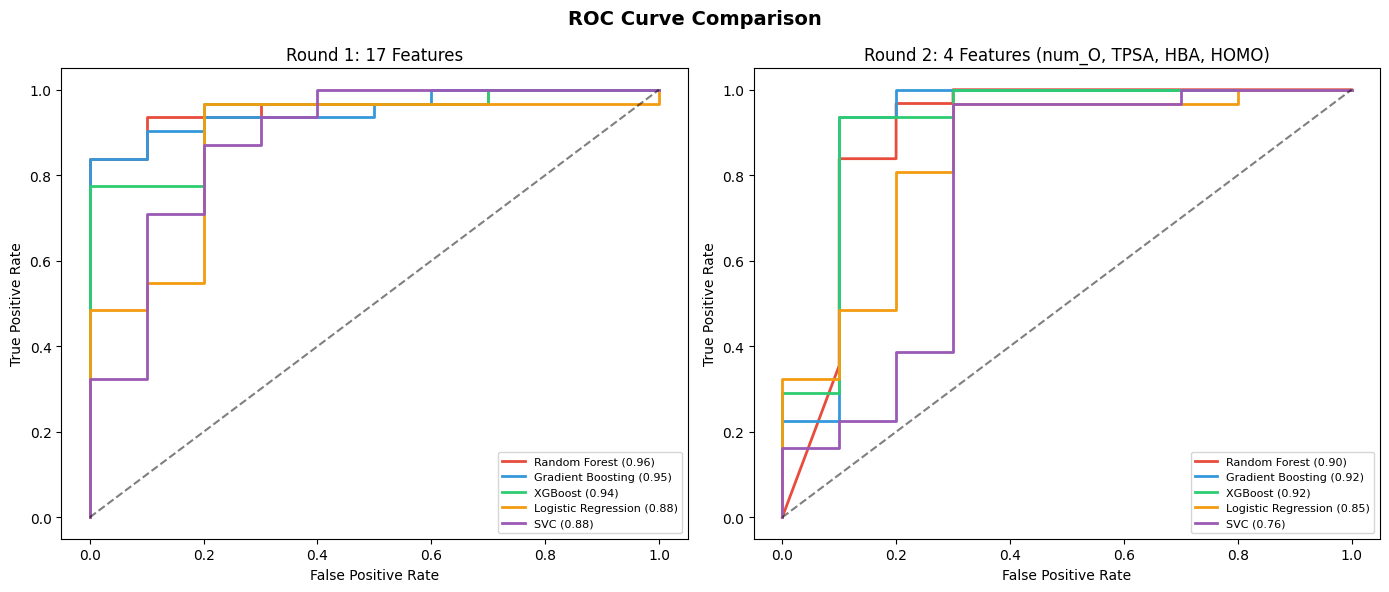

In [3]:
# Side-by-side ROC comparison
from src.visualization import save_fig

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

for (name, res), color in zip(r1['results'].items(), colors):
    ax1.plot(res["fpr"], res["tpr"], label=f'{name} ({res["auc"]:.2f})', color=color, linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Round 1: 17 Features")
ax1.legend(fontsize=8)

for (name, res), color in zip(r2['results'].items(), colors):
    ax2.plot(res["fpr"], res["tpr"], label=f'{name} ({res["auc"]:.2f})', color=color, linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Round 2: 4 Features (num_O, TPSA, HBA, HOMO)")
ax2.legend(fontsize=8)

plt.suptitle("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, "roc_comparison.png")
plt.show()

Saved: /home/yhm/desktop/code/anion-paper/figures/feature_importance_top4.png


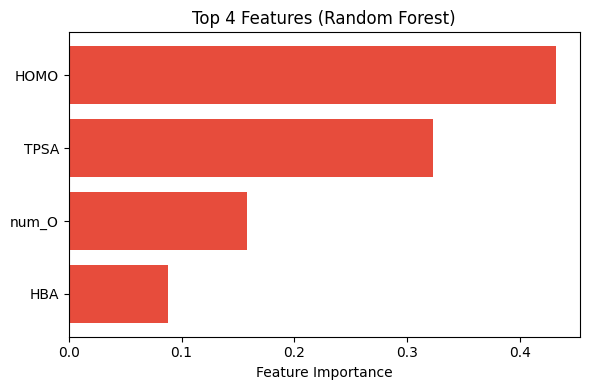

In [4]:
# Feature importance summary
from src.models import get_feature_importance

rf_r2 = r2['results']['Random Forest']['model']
imp_r2 = get_feature_importance(rf_r2, r2['feature_names'])

fig, ax = plt.subplots(figsize=(6, 4))
feats = list(imp_r2.keys())
vals = [imp_r2[f] for f in feats]
sorted_idx = np.argsort(vals)
ax.barh(range(len(feats)), [vals[i] for i in sorted_idx], color='#e74c3c')
ax.set_yticks(range(len(feats)))
ax.set_yticklabels([feats[i] for i in sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_title("Top 4 Features (Random Forest)")
plt.tight_layout()
save_fig(fig, "feature_importance_top4.png")
plt.show()

In [5]:
# Paper summary
print("=" * 70)
print("REPRODUCTION SUMMARY")
print("=" * 70)
print(f"Paper: Xu et al., Nat. Mater. 22, 1507-1514 (2023)")
print(f"DOI: 10.1038/s41563-023-01705-y")
print(f"")
print(f"Dataset: 267 PH anions, 19 features")
print(f"  - High Eb (>3 eV): 201 (75.3%)")
print(f"  - Low Eb (<=3 eV): 66 (24.7%)")
print(f"")
print(f"ML Protocol:")
print(f"  - Round 1: Remove MPI, La \u2192 17 features")
print(f"  - Round 2: Top 4 features: num_O, TPSA, HBA, HOMO")
print(f"  - Split: 85%/15% StratifiedShuffleSplit")
print(f"  - CV: 10-fold StratifiedShuffleSplit")
print(f"")
print(f"Results (Random Forest, 4 features):")
cv = r2.get('cv_results', r2.get('cv'))
print(f"  Our reproduction: AUC = {cv['auc_mean']:.2f} \u00b1 {cv['auc_std']:.2f}")
print(f"  Paper reports:    AUC = 0.87 \u00b1 0.06")
print(f"  Our accuracy:     {cv['acc_mean']:.2f} \u00b1 {cv['acc_std']:.2f}")
print(f"  Paper reports:    Accuracy = 0.84")
print(f"")
print(f"Key findings confirmed:")
print(f"  1. More num_O \u2192 stronger Eb (more Pb2+ coordination sites)")
print(f"  2. Larger TPSA \u2192 stronger Eb (more hydrogen bonding)")
print(f"  3. More HBA \u2192 stronger Eb (more H-bond acceptors)")
print(f"  4. Lower HOMO \u2192 stronger Eb (higher electronegativity)")
print("=" * 70)

REPRODUCTION SUMMARY
Paper: Xu et al., Nat. Mater. 22, 1507-1514 (2023)
DOI: 10.1038/s41563-023-01705-y

Dataset: 267 PH anions, 19 features
  - High Eb (>3 eV): 201 (75.3%)
  - Low Eb (<=3 eV): 66 (24.7%)

ML Protocol:
  - Round 1: Remove MPI, La → 17 features
  - Round 2: Top 4 features: num_O, TPSA, HBA, HOMO
  - Split: 85%/15% StratifiedShuffleSplit
  - CV: 10-fold StratifiedShuffleSplit

Results (Random Forest, 4 features):
  Our reproduction: AUC = 0.78 ± 0.07
  Paper reports:    AUC = 0.87 ± 0.06
  Our accuracy:     0.80 ± 0.05
  Paper reports:    Accuracy = 0.84

Key findings confirmed:
  1. More num_O → stronger Eb (more Pb2+ coordination sites)
  2. Larger TPSA → stronger Eb (more hydrogen bonding)
  3. More HBA → stronger Eb (more H-bond acceptors)
  4. Lower HOMO → stronger Eb (higher electronegativity)
